In [19]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

In [20]:
vehiclesdf_unclean = pd.read_csv("vehicles.csv")

vehiclesdfc = vehiclesdf_unclean[["id","region","region_url","price","year","manufacturer","model","condition","cylinders","state","posting_date"]]

print("Loaded Data")

Loaded Data


In [21]:
vehiclesdfc.head()

,id,region,region_url,price,year,manufacturer,model,condition,cylinders,state,posting_date
0,7222695916,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,az,NaN
1,7218891961,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,ar,NaN
2,7221797935,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,fl,NaN
3,7222270760,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,ma,NaN
4,7210384030,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,nc,NaN


In [22]:
before = vehiclesdfc.shape
print(vehiclesdfc.shape)
print(" ")
print(vehiclesdfc.info())
print(vehiclesdfc.describe())
print((vehiclesdfc.isnull().sum() / len(vehiclesdfc)) * 100)

(426880, 11)
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   region_url    426880 non-null  object 
 3   price         426880 non-null  int64  
 4   year          425675 non-null  float64
 5   manufacturer  409234 non-null  object 
 6   model         421603 non-null  object 
 7   condition     252776 non-null  object 
 8   cylinders     249202 non-null  object 
 9   state         426880 non-null  object 
 10  posting_date  426812 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 35.8+ MB
None
                 id         price           year
count  4.268800e+05  4.268800e+05  425675.000000
mean   7.311487e+09  7.519903e+04    2011.235191
std    4.473170e+06  1.218228e+07       9.452120
min    7.207408e+09  0.000000e+00    1

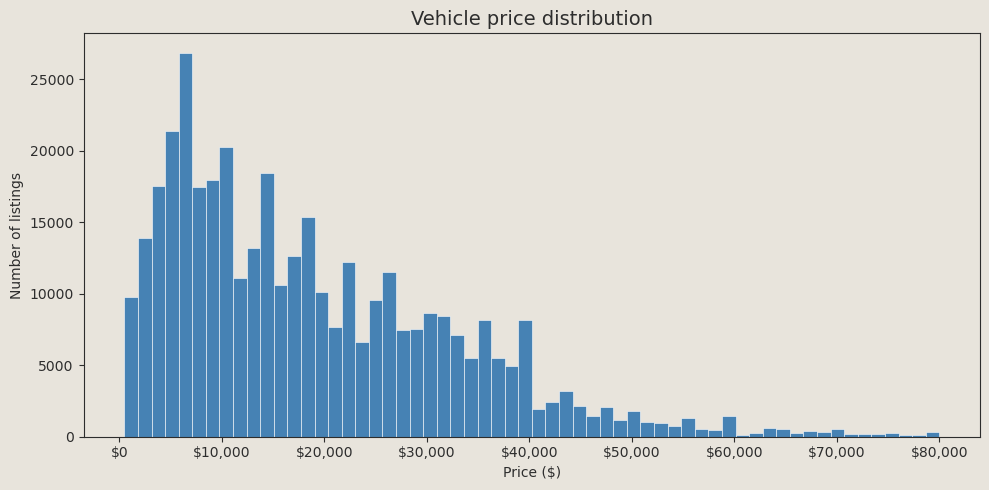

In [25]:
bg_color = "#E8E4DC"
text_color = "#2D2D2D"

df_plot = vehiclesdfc[vehiclesdfc['price'].between(500, 80000)]
fig, ax = plt.subplots(figsize=(10, 5), facecolor=bg_color)
ax.set_facecolor(bg_color)
ax.hist(df_plot['price'], bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_title('Vehicle price distribution', fontsize=14, color=text_color)
ax.set_xlabel('Price ($)', color=text_color)
ax.set_ylabel('Number of listings', color=text_color)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x):,}'))
ax.tick_params(colors=text_color)
for spine in ax.spines.values():
    spine.set_edgecolor(text_color)
plt.tight_layout()
plt.show()

In [26]:
# Due to condition and cylinders being at 40% with nAN values then we should drop it 
vehiclesdfc = vehiclesdfc.drop(columns=["condition", "cylinders"])
vehiclesdfc = vehiclesdfc.dropna()

In [27]:
vehiclesdfc.head()

,id,region,region_url,price,year,manufacturer,model,state,posting_date
27,7316814884,auburn,https://auburn.craigslist.org,33590,2014.0,gmc,sierra 1500 crew cab slt,al,2021-05-04T12:31:18-0500
28,7316814758,auburn,https://auburn.craigslist.org,22590,2010.0,chevrolet,silverado 1500,al,2021-05-04T12:31:08-0500
29,7316814989,auburn,https://auburn.craigslist.org,39590,2020.0,chevrolet,silverado 1500 crew,al,2021-05-04T12:31:25-0500
30,7316743432,auburn,https://auburn.craigslist.org,30990,2017.0,toyota,tundra double cab sr,al,2021-05-04T10:41:31-0500
31,7316356412,auburn,https://auburn.craigslist.org,15000,2013.0,ford,f-150 xlt,al,2021-05-03T14:02:03-0500


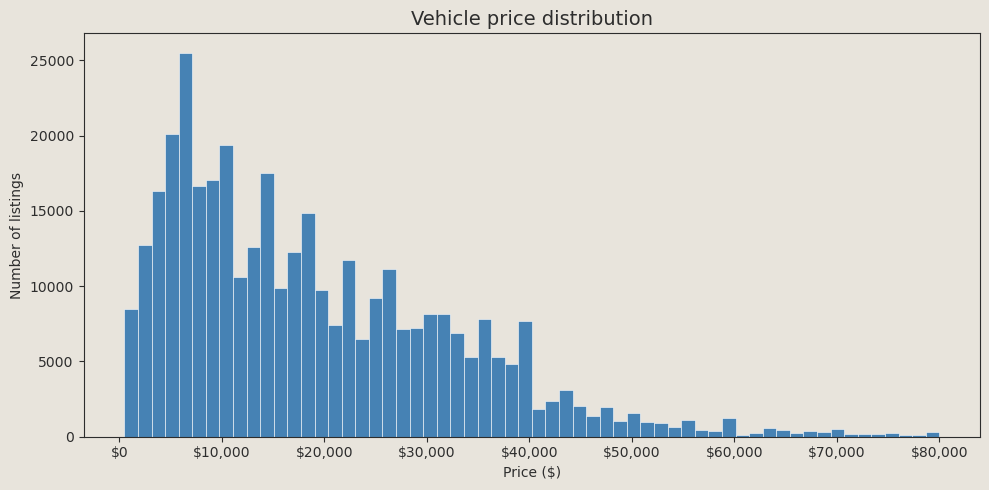

In [28]:
bg_color = "#E8E4DC"
text_color = "#2D2D2D"

df_plot = vehiclesdfc[vehiclesdfc['price'].between(500, 80000)]
fig, ax = plt.subplots(figsize=(10, 5), facecolor=bg_color)
ax.set_facecolor(bg_color)
ax.hist(df_plot['price'], bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_title('Vehicle price distribution', fontsize=14, color=text_color)
ax.set_xlabel('Price ($)', color=text_color)
ax.set_ylabel('Number of listings', color=text_color)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x):,}'))
ax.tick_params(colors=text_color)
for spine in ax.spines.values():
    spine.set_edgecolor(text_color)
plt.tight_layout()
plt.show()

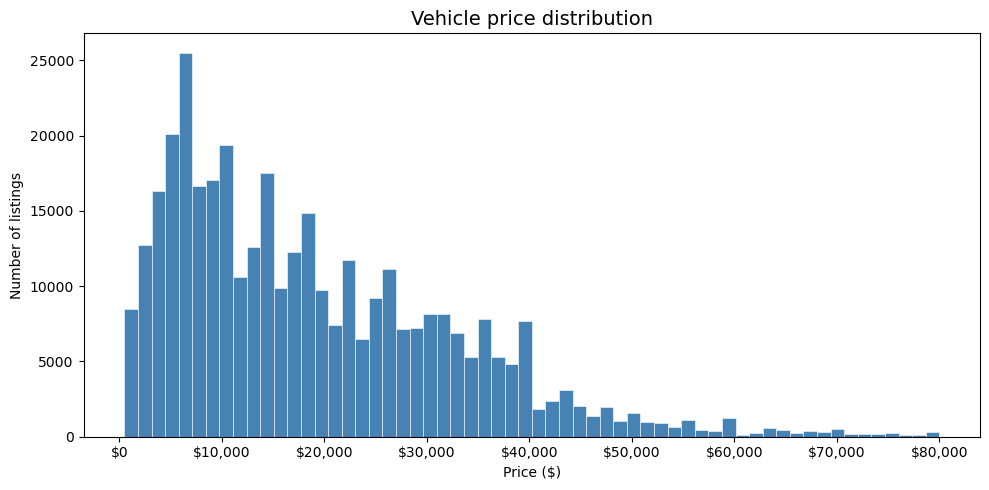

In [29]:
# Filter out extreme outliers first
df_plot = vehiclesdfc[vehiclesdfc['price'].between(500, 80000)]

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df_plot['price'], bins=60, color='steelblue', edgecolor='white', linewidth=0.4)

ax.set_title('Vehicle price distribution', fontsize=14)
ax.set_xlabel('Price ($)')
ax.set_ylabel('Number of listings')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x):,}'))

plt.tight_layout()
plt.show()

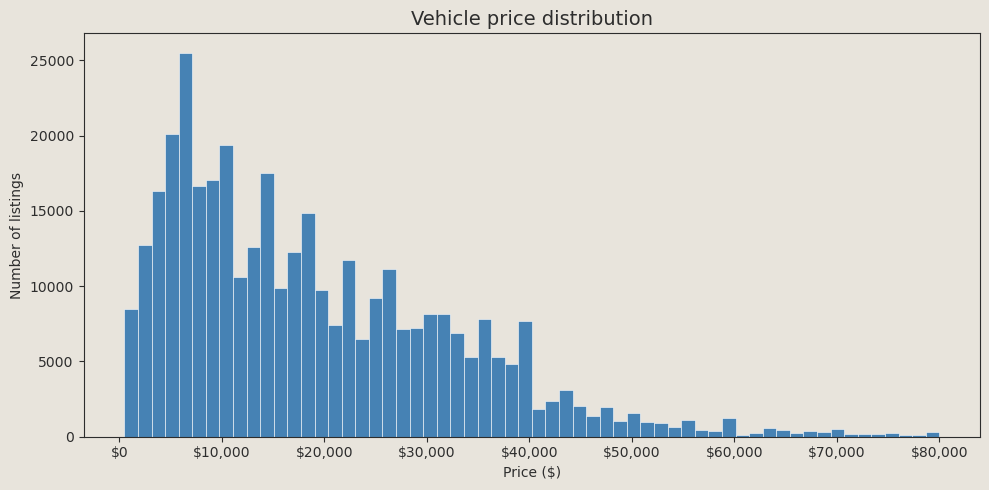

In [30]:
bg_color = "#E8E4DC"
text_color = "#2D2D2D"

df_plot = vehiclesdfc[vehiclesdfc['price'].between(500, 80000)]
fig, ax = plt.subplots(figsize=(10, 5), facecolor=bg_color)
ax.set_facecolor(bg_color)
ax.hist(df_plot['price'], bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_title('Vehicle price distribution', fontsize=14, color=text_color)
ax.set_xlabel('Price ($)', color=text_color)
ax.set_ylabel('Number of listings', color=text_color)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x):,}'))
ax.tick_params(colors=text_color)
for spine in ax.spines.values():
    spine.set_edgecolor(text_color)
plt.tight_layout()
plt.show()

In [31]:
print(vehiclesdfc.shape)
print(" ")
print(vehiclesdfc.info())
print(vehiclesdfc.describe())
print((vehiclesdfc.isnull().sum() / len(vehiclesdfc)) * 100)

(404020, 9)
 
<class 'pandas.core.frame.DataFrame'>
Index: 404020 entries, 27 to 426879
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            404020 non-null  int64  
 1   region        404020 non-null  object 
 2   region_url    404020 non-null  object 
 3   price         404020 non-null  int64  
 4   year          404020 non-null  float64
 5   manufacturer  404020 non-null  object 
 6   model         404020 non-null  object 
 7   state         404020 non-null  object 
 8   posting_date  404020 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 30.8+ MB
None
                 id         price           year
count  4.040200e+05  4.040200e+05  404020.000000
mean   7.311503e+09  6.218580e+04    2011.657180
std    4.374469e+06  1.124254e+07       8.570535
min    7.301583e+09  0.000000e+00    1900.000000
25%    7.308152e+09  5.995000e+03    2009.000000
50%    7.312635e+09  1.399500e+04 

In [32]:

Before = (426880, 11)
After = (404020, 9)
print(426880-404020)

22860
